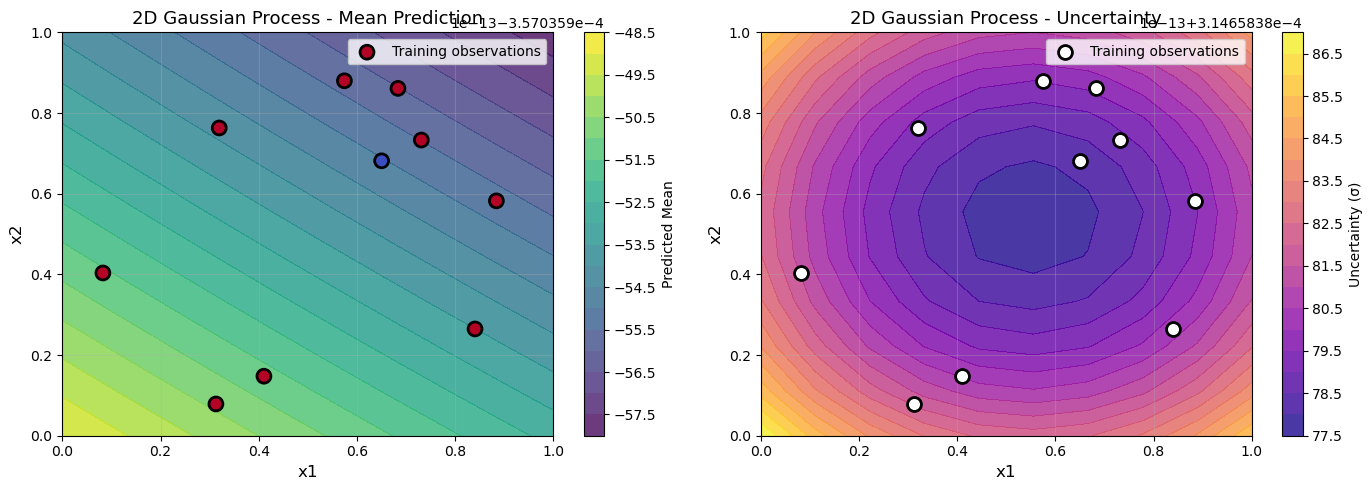

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import ipdb
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from misc_plotting_utils import (
    plot_gp_2d
)

# Random observation points
X_train = np.load('./function_1/initial_inputs.npy')
Y_train = np.load('./function_1/initial_outputs.npy')

x1_grid = np.linspace(0, 1, len(X_train))
x2_grid = np.linspace(0, 1, len(X_train))
# %debug
# ipdb.set_trace()
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_test = np.c_[X1.ravel(), X2.ravel()]

# Create Gaussian Process
kernel = ConstantKernel(1.0) * RBF(length_scale=0.1)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10)

# Fit your GP and made predictions
gp.fit(X_train, Y_train)
mu, sigma = gp.predict(X_test, return_std=True)

# reshape mean and sigma
mu = mu.reshape(X1.shape)
sigma = sigma.reshape(X1.shape)

# Plot
plot_gp_2d(X_train, Y_train, X1, X2, mu, sigma)
plt.show()